In [ ]:
!pip install --upgrade google-cloud-bigquery


In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery


project_id = "cmpe138sp25"
client = bigquery.Client(project=project_id)

print("Using project:", client.project)


Using project: cmpe138sp25


                date  NO2_concentration  temp  prcp city_name wind_speed  \
0         2018-01-01          23.165217  52.1  0.00  San Jose        8.6   
1         2018-01-01          23.165217  50.9  0.00  San Jose        9.7   
2         2018-01-01          23.165217  38.4  0.00  San Jose        3.9   
3         2018-01-01          23.165217  40.8  0.00  San Jose        7.3   
4         2018-01-01          23.165217  63.5  0.00  San Jose        0.7   
...              ...                ...   ...   ...       ...        ...   
34631343  2024-01-01          13.469565  54.3  0.12  San Jose        7.9   
34631344  2024-01-01          13.469565  30.4  0.14  San Jose      999.9   
34631345  2024-01-01          13.469565  24.3  0.00  San Jose        6.0   
34631346  2024-01-01          13.469565  78.0  0.04  San Jose        7.3   
34631347  2024-01-01          13.469565  72.5  0.00  San Jose        4.3   

          county_name  
0         Santa Clara  
1         Santa Clara  
2         Santa

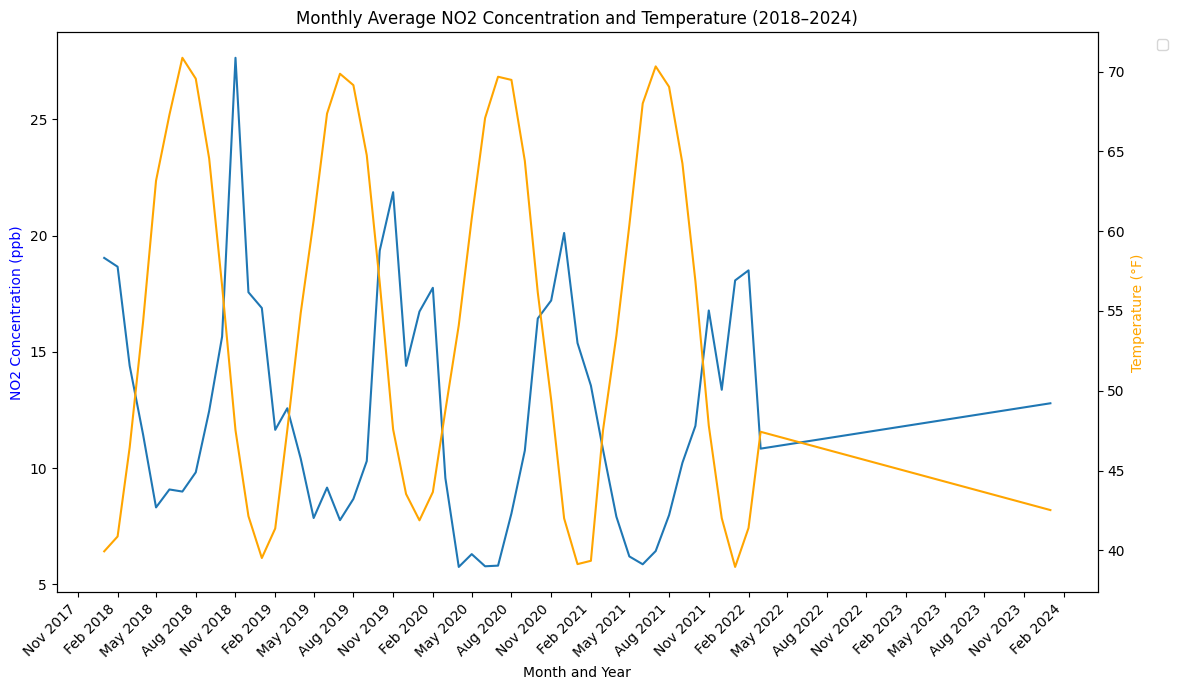

Pearson correlation between NO2 concentration and temperature: -0.698


In [ ]:
query_ahmed2_medOptimal = """
WITH weather_data AS (
  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2018`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2019`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2020`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2021`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2022`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2023`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2024`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'
)


SELECT
  t1.date_local AS date,
  t1.arithmetic_mean AS NO2_concentration,
  t2.temp,
  t2.prcp,
  t2.wdsp AS wind_speed,
  t1.county_name,
FROM
  `bigquery-public-data.epa_historical_air_quality.no2_daily_summary` AS t1
LEFT JOIN weather_data AS t2
ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))
WHERE
  t1.state_name = 'California'
  AND t1.county_name LIKE 'Santa Clara'
  AND t1.date_local BETWEEN '2018-01-01' AND '2024-01-01'
ORDER BY
  date ASC;
"""
query_optimized=  """
WITH weather_data AS (
  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod*`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'
)


SELECT
  t1.date_local AS date,
  t1.arithmetic_mean AS NO2_concentration,
  t2.temp,
  t2.prcp, t1.city_name,
  t2.wdsp AS wind_speed,
  t1.county_name,
FROM
  `bigquery-public-data.epa_historical_air_quality.no2_daily_summary` AS t1
LEFT JOIN weather_data AS t2
ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))
WHERE
  t1.state_name = 'California'
  AND t1.county_name LIKE 'Santa Clara'
  AND t1.date_local BETWEEN '2018-01-01' AND '2024-01-01' AND t1.city_name = 'San Jose'
ORDER BY
  date ASC;
"""
query_ahmed2_unoptimized="""
                        SELECT
                          t1.date_local AS date,
                          t1.arithmetic_mean AS NO2_concentration,
                          t2.temp,
                          t2.prcp,
                          t1.city_name,
                          t2.wdsp AS wind_speed,
                          t1.county_name,
                          s.name AS station_name
                        FROM
                          `bigquery-public-data.epa_historical_air_quality.no2_daily_summary` AS t1
                        LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2018` AS t2
                        ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))

                        LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2019` AS t3
                        ON t1.date_local = DATE(CAST(t3.year AS INT64), CAST(t3.mo AS INT64), CAST(t3.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2020` AS t4
                        ON t1.date_local = DATE(CAST(t4.year AS INT64), CAST(t4.mo AS INT64), CAST(t4.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2021` AS t5
                        ON t1.date_local = DATE(CAST(t5.year AS INT64), CAST(t5.mo AS INT64), CAST(t5.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2022` AS t6
                        ON t1.date_local = DATE(CAST(t6.year AS INT64), CAST(t6.mo AS INT64), CAST(t6.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2023` AS t7
                        ON t1.date_local = DATE(CAST(t7.year AS INT64), CAST(t7.mo AS INT64), CAST(t7.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2024` AS t8
                        ON t1.date_local = DATE(CAST(t8.year AS INT64), CAST(t8.mo AS INT64), CAST(t8.da AS INT64))


                        LEFT JOIN
                          `bigquery-public-data.noaa_gsod.stations` AS s
                        ON
                          t2.stn = s.usaf AND t2.wban = s.wban AND  t3.stn = s.usaf AND t3.wban = s.wban AND  t4.stn = s.usaf AND t4.wban = s.wban AND  t5.stn = s.usaf AND t5.wban = s.wban AND  t6.stn = s.usaf AND t6.wban = s.wban AND  t7.stn = s.usaf AND t7.wban = s.wban AND  t8.stn = s.usaf AND t8.wban = s.wban
                          AND s.state = 'CA'
                          AND s.name LIKE 'SAN JOSE%'
                        WHERE
                          t1.state_name = 'California'
                          AND t1.county_name LIKE 'Santa Clara'
                          AND t1.date_local BETWEEN '2018-01-01' AND '2024-01-01'
                        ORDER BY
                          date ASC;


"""
query_job = client.query(query_optimized)
results1 = query_job.result().to_dataframe()

print(results1)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.dates as mdates

# Ensure 'date' column is datetime
results1['date'] = pd.to_datetime(results1['date'])

# Extract month for grouping
results1['month'] = results1['date'].dt.to_period('M')

# Group by month and compute averages
monthly_avg = results1.groupby('month').agg({
    'NO2_concentration': 'mean',
    'temp': 'mean'
}).reset_index()

# Convert Period to datetime for plotting
monthly_avg['month'] = monthly_avg['month'].dt.to_timestamp()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(14, 7))

# Set x-axis formatting BEFORE plotting
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Plot NO2 on left y-axis
sns.lineplot(data=monthly_avg, x='month', y='NO2_concentration', ax=ax1)
ax1.set_xlabel('Month and Year')
ax1.set_ylabel('NO2 Concentration (ppb)', color='blue')

# Create right y-axis and plot temperature
ax2 = ax1.twinx()
sns.lineplot(data=monthly_avg, x='month', y='temp', ax=ax2, color='orange')
ax2.set_ylabel('Temperature (°F)', color='orange')

# Improve x-axis tick visibility
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.05, 1), loc='upper left')

# Title and layout
plt.title('Monthly Average NO2 Concentration and Temperature (2018–2024)')
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make space for legend

plt.show()

# Calculate and print Pearson correlation
correlation = monthly_avg['NO2_concentration'].corr(monthly_avg['temp'])
print(f"Pearson correlation between NO2 concentration and temperature: {correlation:.3f}")
